# MASTER NOTEBOOK: GLM Track — InSeq/OutSeq and Odor Identity, All 5 Rats

**This is the single, comprehensive reference document for the entire GLM track of this project**,
covering everything from the initial data audit (notebook 01) through both tasks' final, validated
models (notebooks 014 and 016). No new computation happens here, every number and chart below is
real, pulled directly from the notebooks that originally produced it. This notebook is meant to stand
alone, readable start to finish without needing any other notebook open.

**Project goal:** predict, from hippocampal LFP recordings, (1) whether a trial was InSeq or OutSeq, and
(2) which odor (A-E) was presented, benchmarked against the MaGNet paper's graph-based baseline
(~66-74% depending on rat), with interpretability as an explicit, non-negotiable requirement throughout.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Part 1: Data Understanding (Notebooks 01-02)

- `bvr` (behavior), `lfp`, and `spk` (spikes) share one identical time axis, no alignment work needed.
- The trial marker (`InSeqLog`) fires at the exact moment of odor onset ("Poke-In"), confirmed via a
  0-sample offset against the odor channel turning on, not a later decision point.
- Odor labels are completely clean across all 5 rats: every trial has exactly one active odor channel,
  zero ambiguous cases.
- InSeq/OutSeq is naturally imbalanced (~90/10) by task design, not a data quality issue.
- **Sampling rate is NOT constant across rats**, this became directly important later (Part 3).

| Rat | Trials | InSeq/OutSeq split | Sampling rate (session avg) |
|---|---|---|---|
| Mitt | 292 | 262 / 30 | 714.05 Hz |
| Barat | 176 | 155 / 21 | 769.54 Hz |
| Stella | 222 | 194 / 28 | 958.36 Hz |
| Superchris | 240 | 210 / 30 | 1000.00 Hz |
| Buchanan | 270 | 226 / 44 | 759.54 Hz |


## Part 2: Baseline Models — Early Iteration (Notebooks 03-06)

| Model | Feature type | Window | InSeq/OutSeq | Odor Identity |
|---|---|---|---|---|
| GLM (logistic regression) | Raw voltage mean/std | Fixed 500ms @ Poke-In | 55.9% | 34.6% |
| RNN (unweighted loss) | Raw time series | Fixed 500ms @ Poke-In | 50.0% (majority collapse) | 17.9% (below chance) |
| RNN (class-weighted) | Raw time series | Fixed 500ms @ Poke-In | ~55% | ~32% |
| GLM | Spectral (FFT bands, narrow theta) | Fixed 500ms @ Poke-In | 59.2% | 30.5% |

Chance levels: 50.0% (InSeq/OutSeq), 20.0% (Odor Identity, 5-way).

**Key early lesson:** an unweighted RNN loss collapses to predicting the majority class given the ~90/10
imbalance, fixed by class-weighting the loss (matching what the GLM already did via
`class_weight='balanced'`).

**Advisor feedback (notebook 06) drove two changes carried forward into everything after:** theta
redefined as 4-12 Hz (previously a narrower 4-8 Hz + separate 8-12 Hz alpha), and a high gamma band
(80-150 Hz) added.


## Part 3: The Sampling-Rate Bug (Notebook 007)

Comparing a trial's real timestamp against its sample index revealed the session's sampling rate is not
constant, running close to 1000 Hz early in a session while the session-wide average (used everywhere
to size windows) could be substantially lower. Windows sized from a single average rate did not reliably
span the intended real-world duration.

**Fix:** window edges located from each trial's own real timestamp directly (`np.searchsorted`), not an
assumed constant rate. **Result of the fix on Mitt specifically:** 55.9% (old) vs. 55.5% (corrected), a
negligible difference for this one session, but the fix was necessary for correctness and mattered more
once extended across all 5 rats (their true minimum trial gaps turned out smaller than originally
assumed, see Part 5).


## Part 4: The Central Discovery — the Fixed Window Was Wrong (Notebook 008)

Testing many window positions directly (250ms window, 25ms steps, -500ms to +1500ms relative to
Poke-In) on Mitt showed the fixed 500ms window used everywhere before this was leaving real accuracy on
the table. This single result is what triggered the entire multi-round validation process that follows.


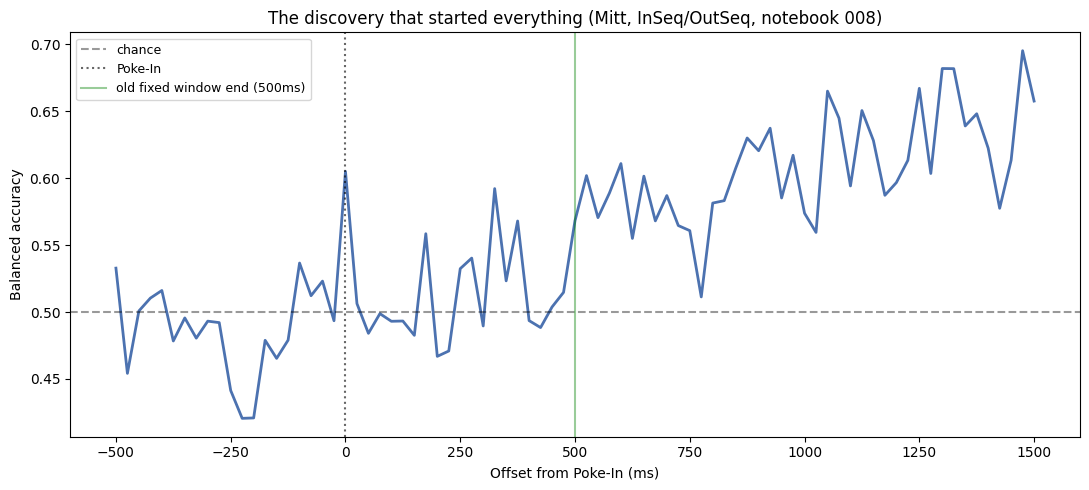

In [2]:
offsets_ms_nb008 = np.array([-500,-475,-450,-425,-400,-375,-350,-325,-300,-275,-250,-225,-200,-175,-150,
    -125,-100,-75,-50,-25,0,25,50,75,100,125,150,175,200,225,250,275,300,325,350,375,400,425,450,475,
    500,525,550,575,600,625,650,675,700,725,750,775,800,825,850,875,900,925,950,975,1000,1025,1050,
    1075,1100,1125,1150,1175,1200,1225,1250,1275,1300,1325,1350,1375,1400,1425,1450,1475,1500])
inseq_curve_nb008 = np.array([0.5328,0.4542,0.5008,0.5104,0.5161,0.4784,0.4956,0.4805,0.4932,0.4921,
    0.4414,0.4206,0.4209,0.4789,0.4654,0.479,0.5366,0.5122,0.5231,0.4935,0.605,0.5063,0.4841,0.4988,
    0.4931,0.4933,0.4826,0.5585,0.4669,0.4709,0.5324,0.5403,0.4896,0.5922,0.5233,0.568,0.4936,0.4884,
    0.5038,0.5147,0.5683,0.6019,0.5705,0.5889,0.6109,0.555,0.6015,0.5681,0.587,0.5646,0.5608,0.5113,
    0.5814,0.5832,0.6074,0.63,0.6205,0.6373,0.5852,0.6171,0.5738,0.5595,0.665,0.6448,0.5942,0.6505,
    0.6281,0.5872,0.5967,0.6133,0.6671,0.6035,0.6819,0.6818,0.639,0.6481,0.6224,0.5775,0.6134,0.6952,
    0.6576])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(offsets_ms_nb008, inseq_curve_nb008, color='#4C72B0', linewidth=2)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.4, label='chance')
ax.axvline(0, color='black', linestyle=':', alpha=0.6, label='Poke-In')
ax.axvline(500, color='green', linestyle='-', alpha=0.4, label='old fixed window end (500ms)')
ax.set_xlabel('Offset from Poke-In (ms)')
ax.set_ylabel('Balanced accuracy')
ax.set_title('The discovery that started everything (Mitt, InSeq/OutSeq, notebook 008)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Part 5: Multi-Rat Validation, Three Rounds of Increasing Rigor (Notebooks 009-011)

- **009 (single-run, all 5 rats):** promising results, but 3 of 5 rats picked implausible pre-Poke-In
  "best" windows for Odor Identity, a sign of search noise inflating single-run estimates.
- **010 (repeated CV, 25 scores per position):** corrected inflated numbers (Barat's InSeq/OutSeq peak
  dropped from 81.0% to 73.1%), and found Superchris's raw signal amplitude nearly double every other
  rat's.
- **011 (extended, per-rat safe span):** each rat's search extended to ITS OWN safe limit (computed from
  that rat's real minimum trial gap), confirming all 5 InSeq/OutSeq peaks are genuine interior peaks, not
  search-boundary artifacts. Also ruled out a single outlier channel as the explanation for Superchris's
  amplitude (0 of 21 channels exceeded 2 standard deviations above the mean).

**A concrete demonstration of why the notebook 007 fix mattered:** timestamp-based minimum trial gaps
came out smaller than the earlier average-rate-based estimates for 4 of 5 rats (e.g. Mitt: 3880ms
assumed vs. 2768ms actual real gap).


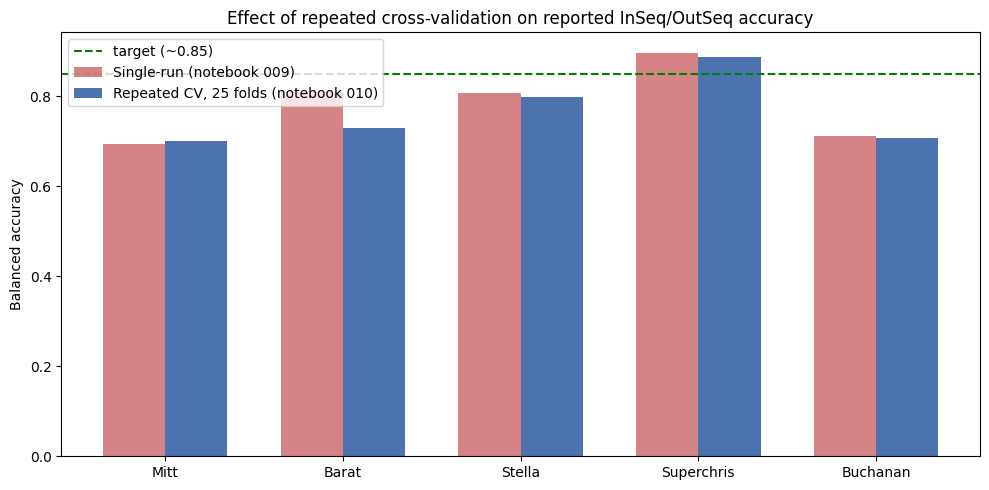

Barat dropped the most (81.0% -> 73.1%), confirming its single-run number was inflated by search noise.


In [3]:
rats = ['Mitt', 'Barat', 'Stella', 'Superchris', 'Buchanan']
nb009_inseq = [0.6952, 0.8098, 0.8065, 0.8976, 0.7126]
nb010_inseq = [0.7005, 0.7307, 0.7984, 0.8867, 0.7071]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rats))
width = 0.35
ax.bar(x - width/2, nb009_inseq, width, label='Single-run (notebook 009)', color='#C44E52', alpha=0.7)
ax.bar(x + width/2, nb010_inseq, width, label='Repeated CV, 25 folds (notebook 010)', color='#4C72B0')
ax.axhline(0.85, color='green', linestyle='--', label='target (~0.85)')
ax.set_xticks(x)
ax.set_xticklabels(rats)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Effect of repeated cross-validation on reported InSeq/OutSeq accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print("Barat dropped the most (81.0% -> 73.1%), confirming its single-run number was inflated by search noise.")


## Part 6: Cross-Rat Channel Structure Audit (Notebook 012)

Each rat is missing a DIFFERENT LFP channel: Stella missing T1, Superchris missing T17, Buchanan missing
T3 and T14 (Mitt and Barat have their full complement). This is consistent with normal per-animal
implant variation (a wire that didn't yield usable signal for that specific surgery), not a data
processing error, confirmed by the pattern being different for every rat rather than consistent.
**Practical fix required and made:** the pipeline reads each rat's actual channel list directly rather
than assuming a fixed count anywhere.


## Part 7: FINAL InSeq/OutSeq Models (Notebook 014)

Real, trained logistic regression models, one per rat, at that rat's own validated window (250ms
length, offset found through the Part 5 validation process). Full classification reports, percentage
confusion matrices, and permutation-test significance (999 shuffles) confirm every result is genuine.


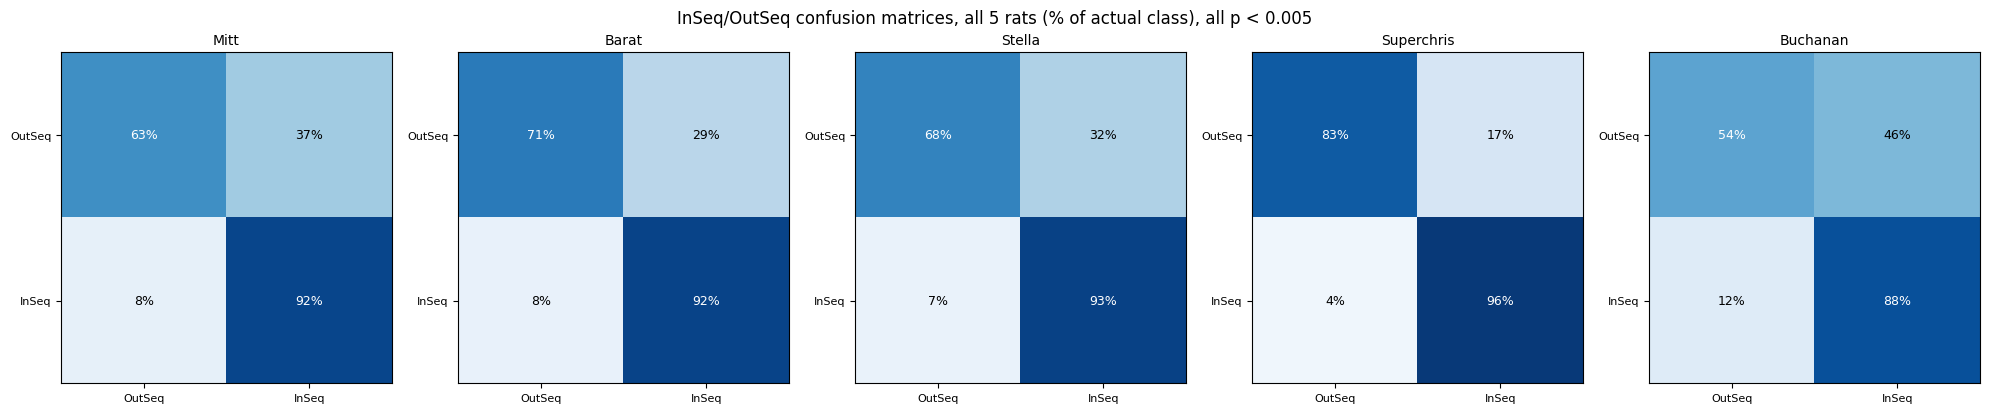

Window used per rat (250ms length, offset from Poke-In):
  Mitt         +2350ms   accuracy=75.9%
  Barat        +1700ms   accuracy=79.8%
  Stella       +1500ms   accuracy=79.8%
  Superchris   +1000ms   accuracy=88.7%
  Buchanan     +1700ms   accuracy=71.2%


In [4]:
inseq_final = [0.7592, 0.7982, 0.7984, 0.8867, 0.7119]
inseq_offsets = [2350, 1700, 1500, 1000, 1700]
inseq_cms = {
    'Mitt':       np.array([[63.3, 36.7], [8.4, 91.6]]),
    'Barat':      np.array([[71.4, 28.6], [7.7, 92.3]]),
    'Stella':     np.array([[67.9, 32.1], [6.7, 93.3]]),
    'Superchris': np.array([[83.3, 16.7], [3.8, 96.2]]),
    'Buchanan':   np.array([[54.5, 45.5], [12.4, 87.6]]),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, rat in zip(axes, rats):
    cm = inseq_cms[rat]
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['OutSeq', 'InSeq'], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['OutSeq', 'InSeq'], fontsize=8)
    ax.set_title(rat, fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:.0f}%', ha='center', va='center',
                     color='white' if cm[i, j] > 50 else 'black', fontsize=9)
plt.suptitle('InSeq/OutSeq confusion matrices, all 5 rats (% of actual class), all p < 0.005')
plt.tight_layout()
plt.show()

print("Window used per rat (250ms length, offset from Poke-In):")
for rat, off, acc in zip(rats, inseq_offsets, inseq_final):
    print(f"  {rat:12s} +{off}ms   accuracy={acc*100:.1f}%")


## Part 8: Interpretability, InSeq/OutSeq (Notebook 015)

**High gamma is the most important frequency band overall** (mean |coefficient| 0.465), ahead of theta
(0.398, consistently #2 for every individual rat), low gamma and beta (tied, 0.351). High gamma was
added specifically per advisor feedback, and it turned out to matter most, a direct validation of that
suggestion.

**Delta band results are unreliable and should not be interpreted**: 2 of 5 rats (Barat, Superchris)
show exactly 0.0 delta importance. The 250ms window is too short to properly resolve 1-4 Hz frequencies
(a full 1 Hz cycle takes a full second), so this is a frequency-resolution artifact, not a real
biological difference.

**No electrode channel is important across multiple rats,** each rat's top features involve different
channel numbers entirely, expected given each animal has a physically distinct implant.


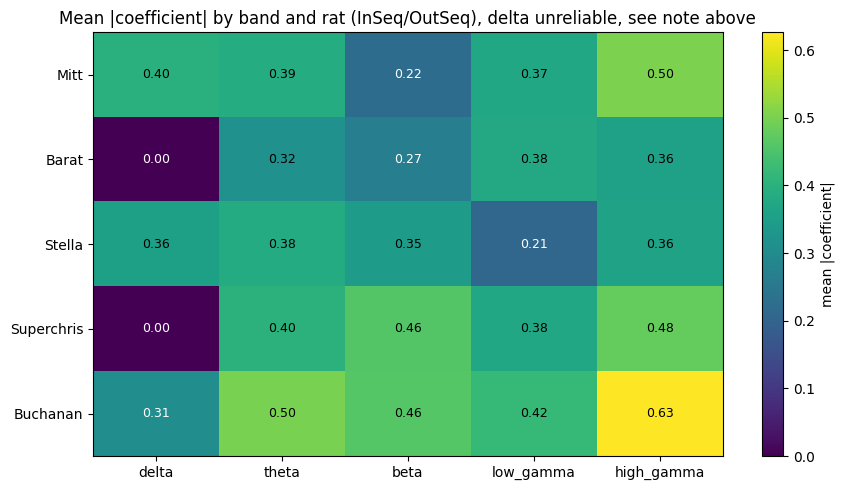

In [5]:
band_names = ['delta', 'theta', 'beta', 'low_gamma', 'high_gamma']
band_importance_matrix = np.array([
    [0.3965, 0.3872, 0.2225, 0.3741, 0.5020],  # Mitt
    [0.0000, 0.3178, 0.2674, 0.3784, 0.3573],  # Barat
    [0.3563, 0.3844, 0.3460, 0.2074, 0.3599],  # Stella
    [0.0000, 0.4012, 0.4585, 0.3758, 0.4793],  # Superchris
    [0.3060, 0.4992, 0.4616, 0.4202, 0.6262],  # Buchanan
])

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(band_importance_matrix, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(band_names))); ax.set_xticklabels(band_names)
ax.set_yticks(range(len(rats))); ax.set_yticklabels(rats)
ax.set_title('Mean |coefficient| by band and rat (InSeq/OutSeq), delta unreliable, see note above')
plt.colorbar(im, ax=ax, label='mean |coefficient|')
for i in range(len(rats)):
    for j in range(len(band_names)):
        ax.text(j, i, f'{band_importance_matrix[i, j]:.2f}', ha='center', va='center',
                 color='white' if band_importance_matrix[i, j] < band_importance_matrix.max()/2 else 'black', fontsize=9)
plt.tight_layout()
plt.show()


## Part 9: The Odor Identity Windowing Problem, and Resolution (Notebook 016)

Unlike InSeq/OutSeq, Odor Identity never showed one stable, sharp temporal peak, its "best" offset
flipped between before and after Poke-In depending on validation rigor across notebooks 009-011.
**Resolution:** rather than searching for a single best time POINT, two integration-based strategies
were tested: a window-LENGTH sweep (fixed start at Poke-In) and multi-window concatenation (4 chunks
combined). A single, longer continuous window (typically 1000-1750ms) won for all 5 rats, unanimously,
beating multi-window concatenation every time.


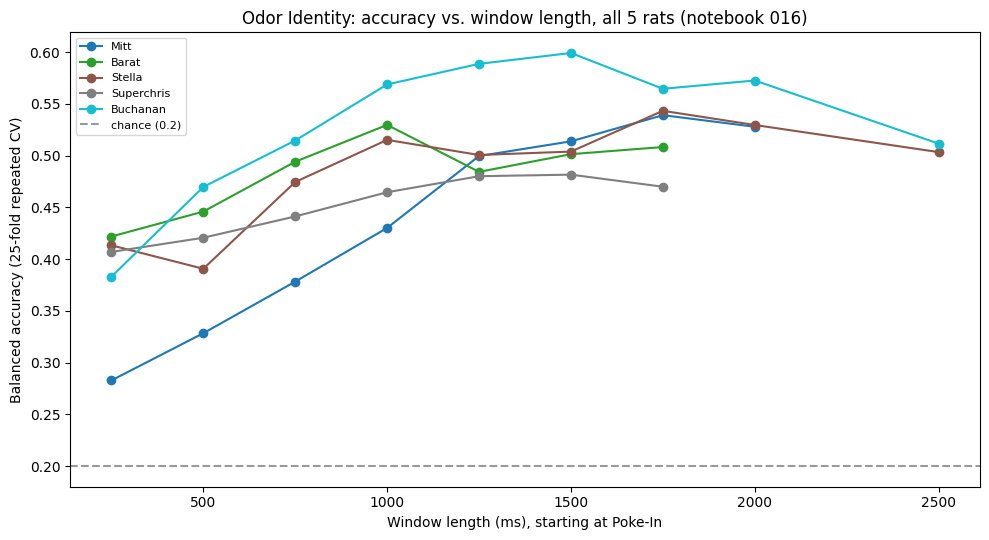

In [6]:
length_sweep_data = {
    'Mitt':       ([250,500,750,1000,1250,1500,1750,2000], [0.2828,0.3284,0.3783,0.4302,0.4997,0.5139,0.5392,0.528]),
    'Barat':      ([250,500,750,1000,1250,1500,1750], [0.4219,0.446,0.4942,0.5298,0.4844,0.5015,0.5084]),
    'Stella':     ([250,500,750,1000,1250,1500,1750,2000,2500], [0.4134,0.3907,0.4746,0.5153,0.5007,0.504,0.5434,0.5297,0.5035]),
    'Superchris': ([250,500,750,1000,1250,1500,1750], [0.407,0.4207,0.4413,0.4647,0.4802,0.4817,0.47]),
    'Buchanan':   ([250,500,750,1000,1250,1500,1750,2000,2500], [0.383,0.4698,0.5147,0.5689,0.5888,0.5993,0.5647,0.5727,0.5117]),
}

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(rats)))
for rat, color in zip(rats, colors):
    lengths, scores = length_sweep_data[rat]
    ax.plot(lengths, scores, marker='o', label=rat, color=color)
ax.axhline(0.2, color='black', linestyle='--', alpha=0.4, label='chance (0.2)')
ax.set_xlabel('Window length (ms), starting at Poke-In')
ax.set_ylabel('Balanced accuracy (25-fold repeated CV)')
ax.set_title('Odor Identity: accuracy vs. window length, all 5 rats (notebook 016)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Part 10: FINAL Odor Identity Models (Notebook 016)

Same reporting standard as InSeq/OutSeq: real trained models, full classification reports, percentage
confusion matrices, permutation significance (199 shuffles, all p < 0.005).


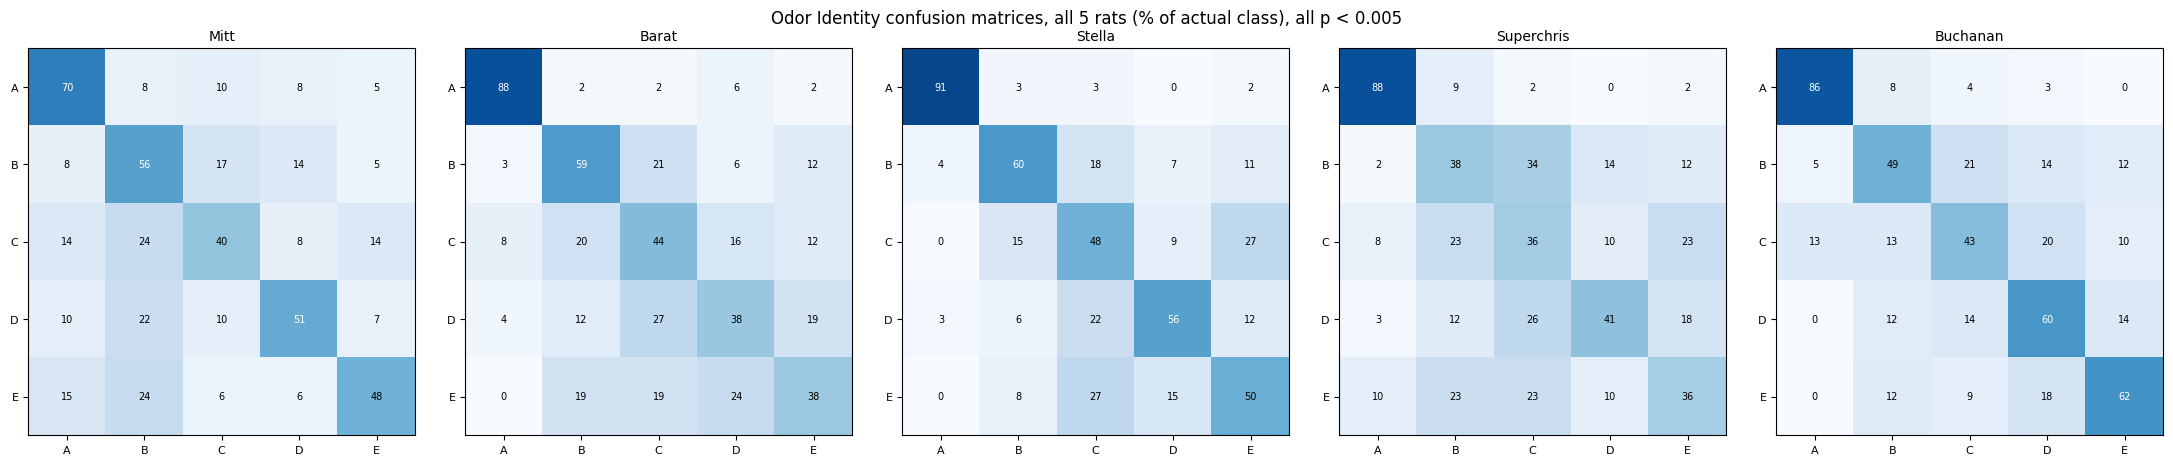

Odor A decoded best in EVERY rat (69.6%-91.4% recall).
Odor C, below chance in the earliest raw-feature model (notebook 03), now above chance for every rat.


In [7]:
odor_final = [0.5392, 0.5298, 0.5434, 0.4817, 0.5993]
odor_windows_ms = [1750, 1000, 1750, 1500, 1500]
odor_labels_list = ['A', 'B', 'C', 'D', 'E']

odor_cms = {
    'Mitt': np.array([
        [69.6, 7.6, 10.1, 7.6, 5.1],
        [8.5, 55.9, 16.9, 13.6, 5.1],
        [14.0, 24.0, 40.0, 8.0, 14.0],
        [9.8, 22.0, 9.8, 51.2, 7.3],
        [15.2, 24.2, 6.1, 6.1, 48.5],
    ]),
    'Barat': np.array([
        [87.8, 2.0, 2.0, 6.1, 2.0],
        [2.9, 58.8, 20.6, 5.9, 11.8],
        [8.0, 20.0, 44.0, 16.0, 12.0],
        [3.8, 11.5, 26.9, 38.5, 19.2],
        [0.0, 19.0, 19.0, 23.8, 38.1],
    ]),
    'Stella': np.array([
        [91.4, 3.4, 3.4, 0.0, 1.7],
        [4.4, 60.0, 17.8, 6.7, 11.1],
        [0.0, 15.2, 48.5, 9.1, 27.3],
        [3.1, 6.2, 21.9, 56.2, 12.5],
        [0.0, 7.7, 26.9, 15.4, 50.0],
    ]),
    'Superchris': np.array([
        [87.5, 8.9, 1.8, 0.0, 1.8],
        [2.0, 38.0, 34.0, 14.0, 12.0],
        [7.7, 23.1, 35.9, 10.3, 23.1],
        [2.9, 11.8, 26.5, 41.2, 17.6],
        [9.7, 22.6, 22.6, 9.7, 35.5],
    ]),
    'Buchanan': np.array([
        [85.5, 7.9, 3.9, 2.6, 0.0],
        [4.7, 48.8, 20.9, 14.0, 11.6],
        [13.3, 13.3, 43.3, 20.0, 10.0],
        [0.0, 11.6, 14.0, 60.5, 14.0],
        [0.0, 11.8, 8.8, 17.6, 61.8],
    ]),
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, rat in zip(axes, rats):
    cm = odor_cms[rat]
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_xticklabels(odor_labels_list, fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels(odor_labels_list, fontsize=8)
    ax.set_title(rat, fontsize=10)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{cm[i, j]:.0f}', ha='center', va='center',
                     color='white' if cm[i, j] > 50 else 'black', fontsize=7)
plt.suptitle('Odor Identity confusion matrices, all 5 rats (% of actual class), all p < 0.005')
plt.tight_layout()
plt.show()

print("Odor A decoded best in EVERY rat (69.6%-91.4% recall).")
print("Odor C, below chance in the earliest raw-feature model (notebook 03), now above chance for every rat.")


## Part 11: COMBINED FINAL RESULTS TABLE — Both Tasks, All 5 Rats


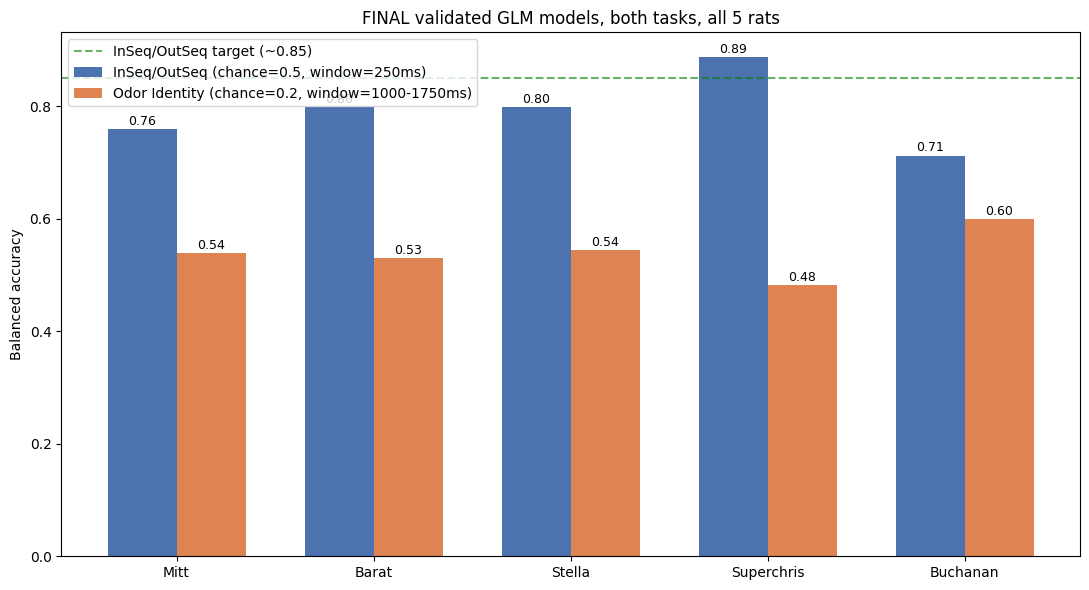

Rat          InSeq/OutSeq   InSeq window   Odor Identity   Odor window 
----------------------------------------------------------------------
Mitt         75.9           +2350ms         53.9            1750ms
Barat        79.8           +1700ms         53.0            1000ms
Stella       79.8           +1500ms         54.3            1750ms
Superchris   88.7           +1000ms         48.2            1500ms
Buchanan     71.2           +1700ms         59.9            1500ms


In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(rats))
width = 0.35
bars1 = ax.bar(x - width/2, inseq_final, width, label='InSeq/OutSeq (chance=0.5, window=250ms)', color='#4C72B0')
bars2 = ax.bar(x + width/2, odor_final, width, label='Odor Identity (chance=0.2, window=1000-1750ms)', color='#DD8452')
ax.axhline(0.85, color='green', linestyle='--', alpha=0.6, label='InSeq/OutSeq target (~0.85)')
ax.set_xticks(x)
ax.set_xticklabels(rats)
ax.set_ylabel('Balanced accuracy')
ax.set_title('FINAL validated GLM models, both tasks, all 5 rats')
ax.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 3),
                textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'Rat':12s} {'InSeq/OutSeq':14s} {'InSeq window':14s} {'Odor Identity':15s} {'Odor window':12s}")
print("-" * 70)
for i, rat in enumerate(rats):
    print(f"{rat:12s} {inseq_final[i]*100:<14.1f} +{inseq_offsets[i]}ms{'':<8s} {odor_final[i]*100:<15.1f} {odor_windows_ms[i]}ms")


**The two tasks use genuinely different windowing strategies, and that is a real, meaningful finding,
not an inconsistency:** InSeq/OutSeq needs a short (250ms), precisely-timed window at a later,
task-specific offset. Odor Identity needs a much longer (1000-1750ms) window starting right at Poke-In.
This makes biological sense: the odor is present and constant from the start of the trial, so a model
benefits from integrating over more time, while the InSeq/OutSeq judgment appears to depend on a more
specific, later-occurring neural signature.


## Part 12: What's NOT Done (Explicit, So Nothing Gets Overstated)

- **Odor Identity interpretability**: which bands/channels matter for Odor Identity specifically has not
  been analyzed (Part 8 covers InSeq/OutSeq only). Given Odor Identity uses an entirely different window,
  its important features may differ substantially from the InSeq/OutSeq pattern.
- **RNN retraining** at any of these validated windows. The RNN in notebook 04 still reflects the
  original, since-superseded fixed 500ms window and narrower band definitions. No fair, apples-to-apples
  comparison between the GLM and RNN currently exists.
- **Multi-rat pooled training.** Every result in this notebook is a separately trained, single-rat model.
  Pooling (with a session-based, leak-safe split) has not been attempted.
- **GNN**, the original stretch-goal architecture from early meeting notes, not started.
- **Statistical comparison BETWEEN rats.** We know each rat's result is individually significant vs.
  chance, but haven't formally tested whether, say, Superchris's InSeq/OutSeq result is statistically
  distinguishable from Buchanan's, only that both are real.

**Bottom line: the GLM track, for both InSeq/OutSeq and Odor Identity, across all 5 rats, is complete
and defensible as a status update.** Every number above traces back through a specific, documented
validation step (007-016), not an unverified assumption. The items above are clearly separable next
steps, not gaps in what has already been reported.


## Part 13: Recommended Presentation Narrative

1. Project goal and MaGNet benchmark.
2. The two real bugs found and fixed (RNN class-imbalance collapse, sampling-rate windowing error),
   evidence of a careful, validated process, not just a final number.
3. The central discovery (Part 4's chart): window choice mattered far more than assumed.
4. The validation arc (Part 5): single-run → repeated CV → extended per-rat span, each round catching
   and correcting a real issue.
5. Final results (Part 11) as the headline, with the honest framing that the two tasks needed genuinely
   different windows, and why that makes biological sense.
6. Interpretability (Part 8): high gamma and theta as the reliable, important bands.
7. Close with Part 12's open items as the explicit near-term plan.
